In [38]:
import pandas as pd
df=pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
#Remove Unnecessary Columns

df=df.drop(columns=["PassengerId","Ticket"])
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C148,C


In [40]:
#Feature Extraction

df["FamilySize"]=df["SibSp"]+df["Parch"]+1
df["IsAlone"]=(df["FamilySize"]==1).astype(int)
df

# Creating these two new feature does not mean we should drop SibSp,Parch feature as it also
# contain useful different information that these newly created feature don't tell us

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilySize,IsAlone
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S,2,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C,2,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S,2,0
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,NaN,S,1,1
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,B42,S,1,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,NaN,S,4,0
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C148,C,1,1


In [41]:
# We can extract the title from NAME , because it converts a high-cardinality feature 
# (Name, where nearly every value is unique) into a low-cardinality categorical feature 
# (Mr, Mrs, Miss, Master, etc.) that carries meaningful information about a passenger's 
# gender, approximate age, marital status, and social status. 
# These characteristics are correlated with survival on the Titanic, making Title a much 
# more informative feature for a machine learning model than the raw Name column.

df["Title"]=df["Name"].str.extract(r",\s*([^\.]+)\.")
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilySize,IsAlone,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,NaN,S,2,0,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C85,C,2,0,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,NaN,S,1,1,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,C123,S,2,0,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,NaN,S,1,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,NaN,S,1,1,Rev
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,B42,S,1,1,Miss
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,NaN,S,4,0,Miss
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C148,C,1,1,Mr


In [42]:
# Check unique values of title column as it may contain some rarely occuring title
# which may occur only few time to REDUCE UNNECESSARY CATEGORIES which will held to reduce
# number of feature after One Hot Encoding

df["Title"].unique()
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [43]:
# Replace rarely occuring title with new title "Rare"
df["Title"]=df["Title"].replace(["Lady","Countess","Capt","Col","Don","Dr","Major","Rev",
                                "Sir","Jonkheer","Dona","the Countess"] , "Rare")

# Replace duplicate title in different language eg Mlle/Ms -> means -> Miss
df["Title"]=df["Title"].replace({
    "Mlle":"Miss",
    "Ms":"Miss",
    "Mme":"Mrs"
})

df["Title"].unique()
df["Title"].value_counts()

# NOW WE HAVE REDUCED 17 CATEGORY TO 5 CATEGORY WHICH WILL HELP TO REDUCE UNNECESSARY FEATURE
# AFTER ONE HOT ENCODING

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [44]:
# Now there is no need of name feature as it carries no meaning and we have exracted 
# meaningful information from it

df=df.drop(columns="Name") # OR df=df.drop("Name", axis=1)

In [45]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilySize,IsAlone,Title
0,0,3,male,22.0,1,0,7.2500,NaN,S,2,0,Mr
1,1,1,female,38.0,1,0,71.2833,C85,C,2,0,Mrs
2,1,3,female,26.0,0,0,7.9250,NaN,S,1,1,Miss
3,1,1,female,35.0,1,0,53.1000,C123,S,2,0,Mrs
4,0,3,male,35.0,0,0,8.0500,NaN,S,1,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,NaN,S,1,1,Rare
887,1,1,female,19.0,0,0,30.0000,B42,S,1,1,Miss
888,0,3,female,NaN,1,2,23.4500,NaN,S,4,0,Miss
889,1,1,male,26.0,0,0,30.0000,C148,C,1,1,Mr


In [46]:
df.isnull().sum()

Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Cabin         687
Embarked        2
FamilySize      0
IsAlone         0
Title           0
dtype: int64

In [47]:
# TRAIN TEST SPLIT

X=df.drop(columns="Survived")
Y=df["Survived"]

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)
#Using stratify=Y preserves the class distribution in both sets.

In [48]:
# Handle Missing Values

#Using sklearn
from sklearn.impute import SimpleImputer
X_train["CabinKnown"]=X_train["Cabin"].notnull().astype(int)
X_test["CabinKnown"]=X_test["Cabin"].notnull().astype(int)
X_train=X_train.drop(columns="Cabin")
X_test=X_test.drop(columns="Cabin")

Age_Imputer=SimpleImputer(strategy="median")
X_train["Age"]=Age_Imputer.fit_transform(X_train[["Age"]]).ravel()
X_test["Age"]=Age_Imputer.transform(X_test[["Age"]]).ravel()

Embarked_Imputer=SimpleImputer(strategy="most_frequent")
X_train["Embarked"]=Embarked_Imputer.fit_transform(X_train[["Embarked"]]).ravel()
X_test["Embarked"]=Embarked_Imputer.transform(X_test[["Embarked"]]).ravel()


In [62]:
# Check Skewness

Skewness=X_train.skew(numeric_only=True)
Skewed_features=Skewness[abs(Skewness)>0.75].index.tolist()
print(Skewed_features)

# Skewness alone is not enough to decide whether to transform a feature. 
# You should consider both the type of feature and its meaning.

# for example here we will get high skewness in 
# ['SibSp', 'Parch', 'Fare', 'FamilySize', 'CabinKnown'] but
# SibSp ❌ (count variable)
# Parch ❌ (count variable)
# CabinKnown ❌ (binary variable)
# Pclass ❌ (ordinal category variable)

# These may have skewness but transforming count, binary, or categorical variable is meaningless

# WE SHOULD ONLY TRANSFORM CONTINUOUS VARIABLE

# Here Fare is continuous variable so we should only transform it

['SibSp', 'Parch', 'Fare', 'FamilySize', 'CabinKnown']


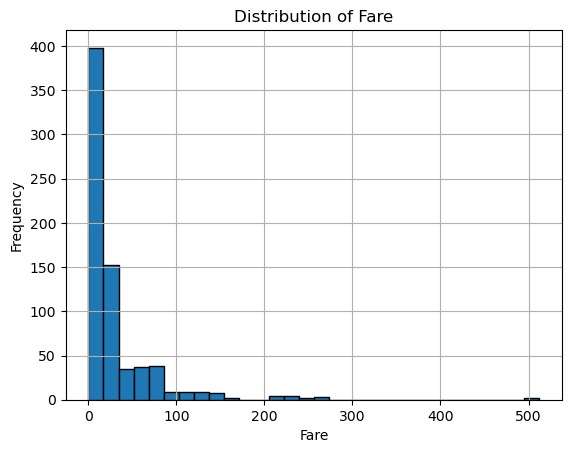

In [64]:
import matplotlib.pyplot as plt

X_train["Fare"].hist(bins=30, edgecolor="black")

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()